In [61]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df = pd.read_csv('/content/review_shopee.csv')

df.head()

,content,score,label
0,fungsi fitur lacak untuk apa klo tidak tau pos...,3,netral
1,lama lama jadi bikin berat sama lemot ke hpnya,2,negatif
2,sangat membantu,4,positif
3,kami minta shoope bisa langsung digunakan tanp...,5,positif
4,peroduk bagus banget,5,positif


In [63]:
df.isnull().sum()

,0
content,0
score,0
label,0


In [64]:
df.dropna(inplace=True)

In [65]:
X = df['content']
y = df['label']

In [66]:
df = df[df['label'] != 'netral']

In [67]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [68]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(X).toarray()

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [70]:
model = Sequential([
    Dense(128, activation='relu',
          input_shape=(X_train.shape[1],)),

    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [71]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [72]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7094 - loss: 1.0024 - val_accuracy: 0.7125 - val_loss: 0.8900
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7250 - loss: 0.7568 - val_accuracy: 0.7125 - val_loss: 0.6749
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7250 - loss: 0.5716 - val_accuracy: 0.7125 - val_loss: 0.5922
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7359 - loss: 0.4517 - val_accuracy: 0.7188 - val_loss: 0.5319
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8547 - loss: 0.3512 - val_accuracy: 0.7875 - val_loss: 0.4729
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9375 - loss: 0.2577 - val_accuracy: 0.8250 - val_loss: 0.4450
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9469 - loss: 0.1886 - val_accuracy: 0.8188 - val_loss: 0.4483
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9516 - loss: 0.1519 - val_accuracy: 0.8375 - v

In [73]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8550 - loss: 0.4146  
Loss : 0.4145592451095581
Accuracy : 0.8550000190734863


In [74]:
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [80]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.86      0.62      0.72        52
           1       0.00      0.00      0.00         5
           2       0.85      0.97      0.91       143

    accuracy                           0.85       200
   macro avg       0.57      0.53      0.54       200
weighted avg       0.83      0.85      0.84       200



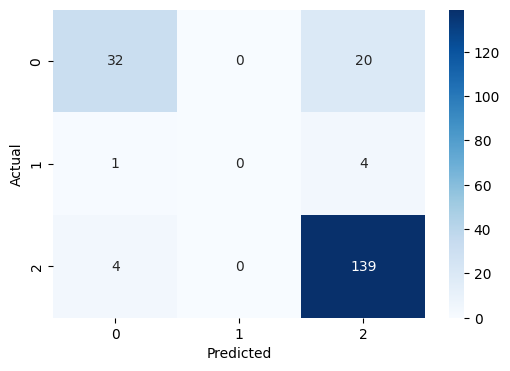

In [76]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [77]:
model.save('model/sentiment_model.h5')

In [78]:
import pickle

with open('model/tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

In [79]:
with open('model/label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)